[np.float64(1.000000000000142), np.float64(434.193602817045)]
Min and max eigenvalues of A :  None
Result summary -----------------
Optimal centralised alpha =  [-0.53657436  0.44107342  0.49718563 -0.13589798  0.90695104 -0.0910655
 -0.46848039  0.83533118 -0.01163214 -0.33866247]


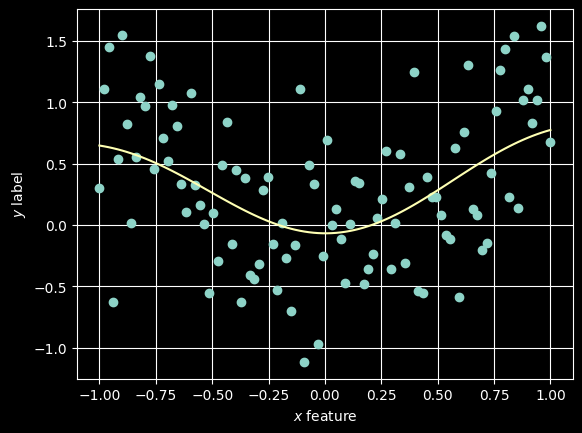

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from utils.dgd import DGD, get_best_L
from utils.essentials import *
from centralized_solution import *

In [2]:
with open("first_database.pkl", "rb") as f:
    x, y = pickle.load(f)
print(type(x), x.shape)
print(type(y))

<class 'numpy.ndarray'> (1000000,)
<class 'numpy.ndarray'>


/var/folders/1v/_q53htts55dbtnw1493wscjc0000gn/T/ipykernel_13357/2161377594.py:2: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  x, y = pickle.load(f)


(1000000,) (1000000,)
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


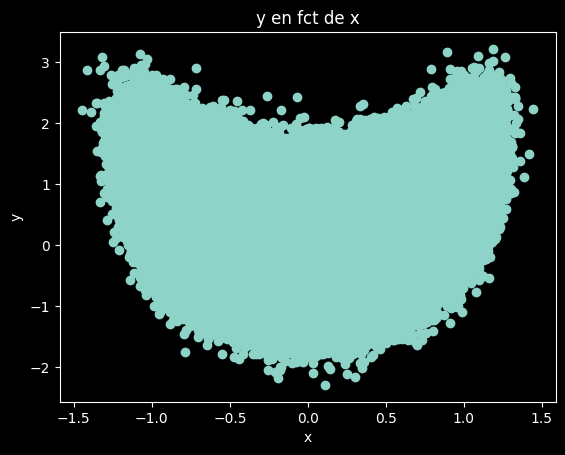

In [3]:
print(x.shape, y.shape)
print(type(x))
print(type(y))
plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("y en fct de x")
plt.show()

In [4]:
# Defining different graph topologies
# 5 agents
# Line graph: 
A_line = np.array([
    [0,1,0,0,0],
    [1,0,1,0,0],
    [0,1,0,1,0],
    [0,0,1,0,1],
    [0,0,0,1,0]
])

# Ring graph
A_ring = np.array([
    [0,1,0,0,1],
    [1,0,1,0,0],
    [0,1,0,1,0],
    [0,0,1,0,1],
    [1,0,0,1,0]
])

# Fully connected
A_full = np.ones((5,5)) - np.eye(5)

# Corresponding weight matrixs

W_line = build_weight_matrix(A_line)
W_full = build_weight_matrix(A_full)
W_ring = build_weight_matrix(A_ring)

In [5]:
# Splitting n = 100 over 5 agents
n_data = 100
n_agents = 5
points_per_agent = n_data // n_agents # 20 per agent here

x_100 = x[:100]
y_100 = y[:100]

agents_x = [x_100[i*20: (i+1)*20] for i in range(n_agents)]
agents_y = [y_100[i*20: (i+1)*20] for i in range(n_agents)]

In [6]:
m = 10
sel = [i for i in range(n_data)]
ind = np.random.choice(sel, m, replace=False)
x_m = [x[i] for i in ind]

In [7]:
alpha_star, ind= solve2(x_100,y_100, x_m)
print(alpha_star)
print(len(alpha_star))

[np.float64(1.0000000000000175), np.float64(474.74115370371504)]
Min and max eigenvalues of A :  None
[-0.09477021  0.73661935  0.1620074  -0.37590499  0.54871912 -0.25087631
 -0.16416128  1.14415886 -0.30247359 -0.33427464]
10


In [8]:
# decentralized gradient descent
L = get_best_L(agents_x, x_m)

# alphas and gaps for different graph topologies
alphas_line, gaps_line = DGD(x_m, agents_x, W_line, agents_y, alpha_star, n_iter = 500, sigma = 0.5, nu = 1.0, eta = 1/L)

alphas_ring, gaps_ring = DGD(x_m, agents_x, W_ring, agents_y, alpha_star, n_iter = 500, sigma = 0.5, nu = 1.0, eta = 1/L)

alphas_full, gaps_full = DGD(x_m, agents_x, W_full, agents_y, alpha_star, n_iter = 500, sigma = 0.5, nu = 1.0, eta = 1/L)
print(alphas_line[-1])

[array([-0.03140818,  0.48878042,  0.10212805, -0.1878018 ,  0.36344176,
       -0.11570801, -0.06850307,  0.57289567, -0.15043524, -0.16772805]), array([-0.04147222,  0.46239222,  0.09511083, -0.20530099,  0.335819  ,
       -0.12842578, -0.07962065,  0.57317683, -0.1722916 , -0.18867966]), array([-0.03933821,  0.44987453,  0.09928203, -0.20812706,  0.323648  ,
       -0.12805466, -0.07818717,  0.58225076, -0.17817198, -0.19390406]), array([-0.02653057,  0.44476774,  0.11405644, -0.20038497,  0.31979052,
       -0.11700578, -0.06607269,  0.601194  , -0.17374756, -0.18875109]), array([ 0.00137174,  0.44412791,  0.14529099, -0.18128678,  0.32094134,
       -0.09215808, -0.03936949,  0.63839543, -0.16022526, -0.17403008])]


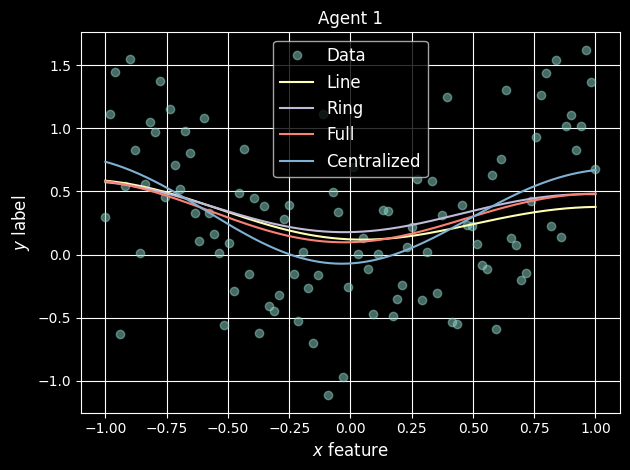

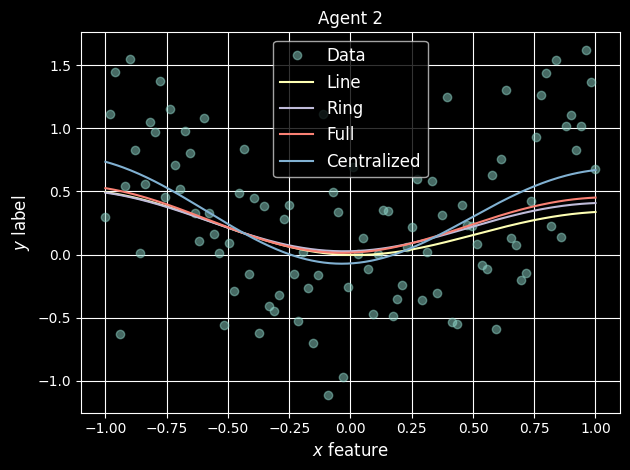

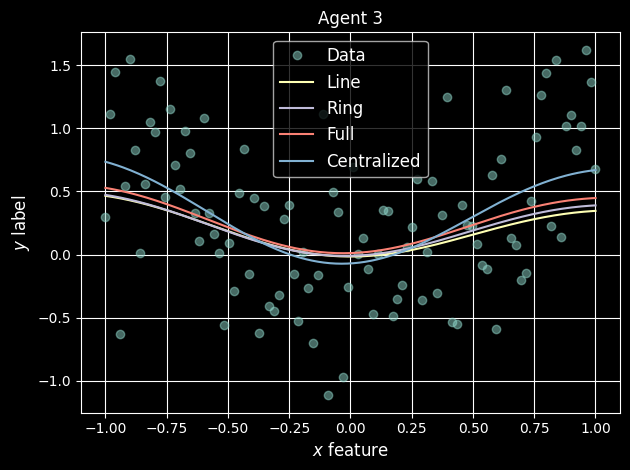

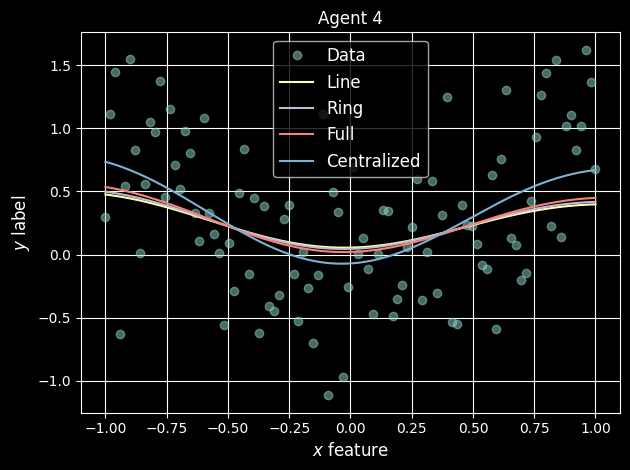

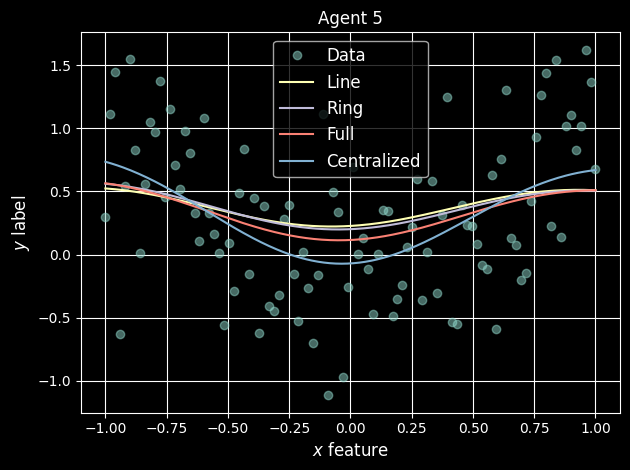

In [18]:
def plot_fit_comparison(x, y, alphas_dict, x_m, agent_idx, nt=250):
    x_prime = np.linspace(-1, 1, nt)
    plt.figure()
    plt.plot(x, y, 'o', label='Data', alpha=0.5)
    for label, alpha in alphas_dict.items():
        y_prime = Cov2(x_prime, x_m) @ alpha[agent_idx]
        plt.plot(x_prime, y_prime, '-', label=label)
    plt.xlabel(r'$x$ feature', fontsize=12)
    plt.ylabel(r'$y$ label', fontsize=12)
    plt.title(f'Agent {agent_idx+1}', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'kernel_fit_agent_{agent_idx+1}.pdf')
    plt.show()

# Call it
alphas_dict = {
    'Line': alphas_line[-1],
    'Ring': alphas_ring[-1],
    'Full': alphas_full[-1],
    'Centralized': [alpha_star] * n_agents 
}

for i in range(n_agents):
    plot_fit_comparison(x_100, y_100, alphas_dict, x_m, agent_idx=i)

(500, 5)


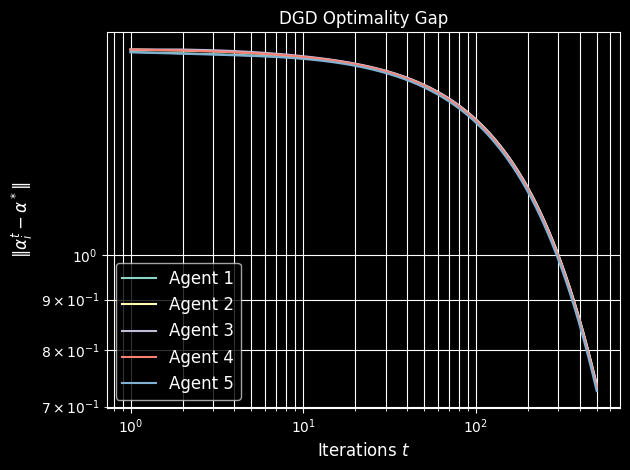

In [ ]:
# Plotting gaps
def plot_gap(gaps, filename='DGD_gap.pdf'):
    gaps = np.array(gaps)  # shape (n_iter, n_agents)
    plt.figure()
    for i in range(gaps.shape[1]):
        plt.loglog(range(1, len(gaps)+1), gaps[:, i], label=f'Agent {i+1}')
    plt.xlabel('Iterations $t$', fontsize=12)
    plt.ylabel(r'$\|\alpha_i^t - \alpha^*\|$', fontsize=12)
    plt.title('DGD Optimality Gap', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, which='both')
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

plot_gap(gaps_line)